# Peak training-memory usage by dataset and method

This notebook discovers every `memory_usage.csv` below `data/models`, reads the corresponding run-level `config.json`, and compares peak incremental CUDA memory across datasets and methods.

For each run:

1. Discard the first `warmup_rows = 3` measurements, then take the maximum `peak_memory_difference_mb` across the remaining steps.
2. Read `training.batch_size.value` from the run configuration and calculate the float32 input-image footprint: MNIST is $1\times28\times28$, CelebA is $3\times64\times64$, and ImageNet is $3\times256\times256$.
3. Use the generative-model parameter counts reported in `UNO/appendix.tex`: 632,788 for MNIST, 8,742,659 for CelebA, and 675.13 million for ImageNet.
4. Plot `model_parameters_millions` on the x-axis and `peak_memory_diff_mb / (batch_size * image_size_mb)` on the y-axis. Image and measured GPU memory use $1024^2$ bytes per MB for consistency with the profiler.

The source CSV column is named `peak_memory_difference_mb`; the analysis uses the requested shorter name `peak_memory_diff_mb` for its standardized output.

In [10]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data" / "models").is_dir():
            return candidate
    raise FileNotFoundError("Could not find data/models from the current directory.")


repo_root = find_repo_root(Path.cwd().resolve())
models_root = repo_root / "data" / "models"
output_csv = models_root / "normalized_peak_memory_summary.csv"
output_plot = models_root / "peak_memory_per_batch_image_mb_vs_model_parameters.png"
warmup_rows = 3

print(f"Repository: {repo_root}")
print(f"Models data: {models_root}")
print(f"Warm-up rows ignored per run: {warmup_rows}")

Repository: /Users/pinak/Documents/Github/forget
Models data: /Users/pinak/Documents/Github/forget/data/models
Warm-up rows ignored per run: 3


## Discover and normalize every run

Method names are inferred from the experiment-folder names. Unknown future folders are retained using a cleaned version of their directory name.

In [11]:
dataset_names = {
    "MNIST-Experiments": "MNIST",
    "CelebA-Experiments": "CelebA",
    "ImageNet-Experiments": "ImageNet",
}

# Generative-model counts from UNO/appendix.tex (not classifier counts).
model_parameter_counts = {
    "MNIST": 632_788,
    "CelebA": 8_742_659,
    "ImageNet": 675_130_000,
}

# Float32 input tensors produced by each dataset's training datapipe.
image_shapes = {
    "MNIST": (1, 28, 28),
    "CelebA": (3, 64, 64),
    "ImageNet": (3, 256, 256),
}
bytes_per_float32 = 4
bytes_per_mb = 1024 ** 2

method_names = {
    "vae-a": "Ascent",
    "vae-ad": "Ascent-Descent",
    "vae-fu": "FU",
    "vae-o": "UNO",
    "vae-os": "UNO-S",
    "vae-s": "Surgery",
    "dit-gandikota-1": "Gandikota",
    "dit-o": "UNO",
    "dit-os": "UNO-S",
    "dit-s": "Surgery",
}

peak_column_candidates = (
    "peak_memory_diff_mb",
    "peak_memory_difference_mb",
)

records = []
for memory_path in sorted(models_root.rglob("memory_usage.csv")):
    relative_parts = memory_path.relative_to(models_root).parts
    if len(relative_parts) < 4:
        raise ValueError(f"Unexpected memory-log path: {memory_path}")

    experiment_group, method_folder, run = relative_parts[:3]
    config_path = memory_path.parent / "config.json"
    if not config_path.is_file():
        raise FileNotFoundError(f"Missing config for {memory_path}: {config_path}")

    memory = pd.read_csv(memory_path)
    peak_column = next(
        (column for column in peak_column_candidates if column in memory.columns),
        None,
    )
    if peak_column is None:
        raise KeyError(
            f"{memory_path} has none of the expected peak columns: "
            f"{peak_column_candidates}"
        )
    if len(memory) <= warmup_rows:
        raise ValueError(
            f"{memory_path} has {len(memory)} rows; cannot discard "
            f"{warmup_rows} warm-up rows and retain a measurement."
        )
    post_warmup_memory = memory.iloc[warmup_rows:]

    with config_path.open() as config_file:
        config = json.load(config_file)
    batch_size = config["training"]["batch_size"]["value"]
    if not isinstance(batch_size, (int, float)) or batch_size <= 0:
        raise ValueError(f"Invalid batch size in {config_path}: {batch_size}")

    peak_memory_diff_mb = pd.to_numeric(
        post_warmup_memory[peak_column], errors="raise"
    ).max()
    dataset = dataset_names.get(
        experiment_group,
        experiment_group.removesuffix("-Experiments"),
    )
    method = method_names.get(
        method_folder,
        method_folder.replace("vae-", "").replace("dit-", ""),
    )
    if dataset not in model_parameter_counts:
        raise KeyError(
            f"No generative-model parameter count is configured for {dataset}."
        )
    model_parameters = model_parameter_counts[dataset]
    model_parameters_millions = model_parameters / 1_000_000
    channels, height, width = image_shapes[dataset]
    image_size_mb = (
        channels * height * width * bytes_per_float32 / bytes_per_mb
    )
    batch_image_size_mb = batch_size * image_size_mb

    records.append({
        "dataset": dataset,
        "method": method,
        "method_folder": method_folder,
        "run": run,
        "memory_rows_total": len(memory),
        "warmup_rows_ignored": warmup_rows,
        "memory_rows_used": len(post_warmup_memory),
        "batch_size": batch_size,
        "model_parameters": model_parameters,
        "model_parameters_millions": model_parameters_millions,
        "image_channels": channels,
        "image_height": height,
        "image_width": width,
        "image_size_mb": image_size_mb,
        "batch_image_size_mb": batch_image_size_mb,
        "peak_memory_diff_mb": peak_memory_diff_mb,
        "normalized_peak_memory_diff_mb_per_sample": (
            peak_memory_diff_mb / batch_size
        ),
        "normalized_peak_memory_diff_mb_per_sample_per_million_parameters": (
            peak_memory_diff_mb / batch_size / model_parameters_millions
        ),
        "normalized_peak_memory_per_batch_image_mb_per_million_parameters": (
            peak_memory_diff_mb / batch_image_size_mb / model_parameters_millions
        ),
        "peak_memory_diff_per_batch_image_mb": (
            peak_memory_diff_mb / batch_image_size_mb
        ),
        "memory_path": str(memory_path.relative_to(repo_root)),
        "config_path": str(config_path.relative_to(repo_root)),
    })

run_memory = pd.DataFrame(records).sort_values(
    ["dataset", "method", "run"],
    ignore_index=True,
)
if run_memory.empty:
    raise RuntimeError(f"No memory_usage.csv files found below {models_root}")

run_memory

,dataset,method,method_folder,run,memory_rows_total,warmup_rows_ignored,memory_rows_used,batch_size,model_parameters,model_parameters_millions,...,image_width,image_size_mb,batch_image_size_mb,peak_memory_diff_mb,normalized_peak_memory_diff_mb_per_sample,normalized_peak_memory_diff_mb_per_sample_per_million_parameters,normalized_peak_memory_per_batch_image_mb_per_million_parameters,peak_memory_diff_per_batch_image_mb,memory_path,config_path
0,CelebA,FU,vae-fu,expr-0,659,3,656,128,8742659,8.742659,...,64,0.046875,6.000000,896.371094,7.002899,0.801003,17.088072,149.395182,data/models/CelebA-Experiments/vae-fu/expr-0/m...,data/models/CelebA-Experiments/vae-fu/expr-0/c...
1,CelebA,Surgery,vae-s,expr-0,659,3,656,128,8742659,8.742659,...,64,0.046875,6.000000,1442.916504,11.272785,1.289400,27.507202,240.486084,data/models/CelebA-Experiments/vae-s/expr-0/me...,data/models/CelebA-Experiments/vae-s/expr-0/co...
2,CelebA,UNO,vae-o,expr-0,659,3,656,128,8742659,8.742659,...,64,0.046875,6.000000,3100.214355,24.220425,2.770373,59.101286,516.702393,data/models/CelebA-Experiments/vae-o/expr-0/me...,data/models/CelebA-Experiments/vae-o/expr-0/co...
3,CelebA,UNO-S,vae-os,expr-0,659,3,656,128,8742659,8.742659,...,64,0.046875,6.000000,3100.219238,24.220463,2.770377,59.101379,516.703206,data/models/CelebA-Experiments/vae-os/expr-0/m...,data/models/CelebA-Experiments/vae-os/expr-0/c...
4,ImageNet,Gandikota,dit-gandikota-1,expr-0,100,3,97,10,675130000,675.130000,...,256,0.750000,7.500000,2580.128418,258.012842,0.382168,0.509557,344.017122,data/models/ImageNet-Experiments/dit-gandikota...,data/models/ImageNet-Experiments/dit-gandikota...
5,ImageNet,Surgery,dit-s,expr-0,100,3,97,10,675130000,675.130000,...,256,0.750000,7.500000,8775.437988,877.543799,1.299815,1.733086,1170.058398,data/models/ImageNet-Experiments/dit-s/expr-0/...,data/models/ImageNet-Experiments/dit-s/expr-0/...
6,ImageNet,UNO,dit-o,expr-0,100,3,97,10,675130000,675.130000,...,256,0.750000,7.500000,52032.551270,5203.255127,7.707042,10.276056,6937.673503,data/models/ImageNet-Experiments/dit-o/expr-0/...,data/models/ImageNet-Experiments/dit-o/expr-0/...
7,ImageNet,UNO-S,dit-os,expr-0,100,3,97,10,675130000,675.130000,...,256,0.750000,7.500000,52043.099121,5204.309912,7.708604,10.278139,6939.079883,data/models/ImageNet-Experiments/dit-os/expr-0...,data/models/ImageNet-Experiments/dit-os/expr-0...
8,MNIST,Ascent,vae-a,expr-0,530,3,527,128,632788,0.632788,...,28,0.002991,0.382812,12.023926,0.093937,0.148449,49.636590,31.409439,data/models/MNIST-Experiments/vae-a/expr-0/mem...,data/models/MNIST-Experiments/vae-a/expr-0/con...
9,MNIST,Ascent-Descent,vae-ad,expr-0,530,3,527,128,632788,0.632788,...,28,0.002991,0.382812,12.802246,0.100018,0.158059,52.849615,33.442602,data/models/MNIST-Experiments/vae-ad/expr-0/me...,data/models/MNIST-Experiments/vae-ad/expr-0/co...


## Aggregate repeated runs

If multiple `expr-*` runs are present for a dataset/method pair, the plot uses their mean and standard deviation. The current folder contains one run per pair.

In [12]:
summary = (
    run_memory.groupby(["dataset", "method"], as_index=False)
    .agg(
        batch_size=("batch_size", "first"),
        warmup_rows_ignored=("warmup_rows_ignored", "first"),
        memory_rows_used=("memory_rows_used", "sum"),
        model_parameters=("model_parameters", "first"),
        model_parameters_millions=("model_parameters_millions", "first"),
        image_channels=("image_channels", "first"),
        image_height=("image_height", "first"),
        image_width=("image_width", "first"),
        image_size_mb=("image_size_mb", "first"),
        batch_image_size_mb=("batch_image_size_mb", "first"),
        runs=("run", "count"),
        peak_memory_diff_mb=("peak_memory_diff_mb", "mean"),
        peak_memory_diff_mb_std=("peak_memory_diff_mb", "std"),
        normalized_peak_memory_diff_mb_per_sample=(
            "normalized_peak_memory_diff_mb_per_sample",
            "mean",
        ),
        normalized_peak_memory_diff_mb_per_sample_std=(
            "normalized_peak_memory_diff_mb_per_sample",
            "std",
        ),
        normalized_peak_memory_diff_mb_per_sample_per_million_parameters=(
            "normalized_peak_memory_diff_mb_per_sample_per_million_parameters",
            "mean",
        ),
        normalized_peak_memory_diff_mb_per_sample_per_million_parameters_std=(
            "normalized_peak_memory_diff_mb_per_sample_per_million_parameters",
            "std",
        ),
        normalized_peak_memory_per_batch_image_mb_per_million_parameters=(
            "normalized_peak_memory_per_batch_image_mb_per_million_parameters",
            "mean",
        ),
        normalized_peak_memory_per_batch_image_mb_per_million_parameters_std=(
            "normalized_peak_memory_per_batch_image_mb_per_million_parameters",
            "std",
        ),
        peak_memory_diff_per_batch_image_mb=(
            "peak_memory_diff_per_batch_image_mb",
            "mean",
        ),
        peak_memory_diff_per_batch_image_mb_std=(
            "peak_memory_diff_per_batch_image_mb",
            "std",
        ),
    )
    .fillna({
        "peak_memory_diff_mb_std": 0.0,
        "normalized_peak_memory_diff_mb_per_sample_std": 0.0,
        "normalized_peak_memory_diff_mb_per_sample_per_million_parameters_std": 0.0,
        "normalized_peak_memory_per_batch_image_mb_per_million_parameters_std": 0.0,
        "peak_memory_diff_per_batch_image_mb_std": 0.0,
    })
)

dataset_order = [
    dataset
    for dataset in ("MNIST", "CelebA", "ImageNet")
    if dataset in set(summary["dataset"])
]
dataset_order += sorted(set(summary["dataset"]) - set(dataset_order))

method_order = [
    method
    for method in (
        "UNO",
        "UNO-S",
        "Surgery",
        "Ascent",
        "Ascent-Descent",
        "FU",
        "Gandikota",
    )
    if method in set(summary["method"])
]
method_order += sorted(set(summary["method"]) - set(method_order))

summary["dataset"] = pd.Categorical(
    summary["dataset"],
    categories=dataset_order,
    ordered=True,
)
summary["method"] = pd.Categorical(
    summary["method"],
    categories=method_order,
    ordered=True,
)
summary = summary.sort_values(["dataset", "method"], ignore_index=True)
summary.to_csv(output_csv, index=False)

summary

,dataset,method,batch_size,warmup_rows_ignored,memory_rows_used,model_parameters,model_parameters_millions,image_channels,image_height,image_width,...,peak_memory_diff_mb,peak_memory_diff_mb_std,normalized_peak_memory_diff_mb_per_sample,normalized_peak_memory_diff_mb_per_sample_std,normalized_peak_memory_diff_mb_per_sample_per_million_parameters,normalized_peak_memory_diff_mb_per_sample_per_million_parameters_std,normalized_peak_memory_per_batch_image_mb_per_million_parameters,normalized_peak_memory_per_batch_image_mb_per_million_parameters_std,peak_memory_diff_per_batch_image_mb,peak_memory_diff_per_batch_image_mb_std
0,MNIST,UNO,128,3,50,632788,0.632788,1,28,28,...,22.046387,0.0,0.172237,0.0,0.272188,0.0,91.010830,0.0,57.590561,0.0
1,MNIST,UNO-S,128,3,50,632788,0.632788,1,28,28,...,22.824707,0.0,0.178318,0.0,0.281797,0.0,94.223855,0.0,59.623724,0.0
2,MNIST,Surgery,128,3,527,632788,0.632788,1,28,28,...,12.019043,0.0,0.093899,0.0,0.148389,0.0,49.616433,0.0,31.396684,0.0
3,MNIST,Ascent,128,3,527,632788,0.632788,1,28,28,...,12.023926,0.0,0.093937,0.0,0.148449,0.0,49.636590,0.0,31.409439,0.0
4,MNIST,Ascent-Descent,128,3,527,632788,0.632788,1,28,28,...,12.802246,0.0,0.100018,0.0,0.158059,0.0,52.849615,0.0,33.442602,0.0
5,MNIST,FU,128,3,50,632788,0.632788,1,28,28,...,11.145996,0.0,0.087078,0.0,0.137610,0.0,46.012363,0.0,29.116071,0.0
6,CelebA,UNO,128,3,656,8742659,8.742659,3,64,64,...,3100.214355,0.0,24.220425,0.0,2.770373,0.0,59.101286,0.0,516.702393,0.0
7,CelebA,UNO-S,128,3,656,8742659,8.742659,3,64,64,...,3100.219238,0.0,24.220463,0.0,2.770377,0.0,59.101379,0.0,516.703206,0.0
8,CelebA,Surgery,128,3,656,8742659,8.742659,3,64,64,...,1442.916504,0.0,11.272785,0.0,1.289400,0.0,27.507202,0.0,240.486084,0.0
9,CelebA,FU,128,3,656,8742659,8.742659,3,64,64,...,896.371094,0.0,7.002899,0.0,0.801003,0.0,17.088072,0.0,149.395182,0.0


## Normalized peak-memory comparison

Both axes are logarithmic. The x-axis is the generative model's parameter count in millions, and the y-axis is peak incremental memory divided by the total float32 input-image memory in the configured batch. Dataset names are annotated beside the UNO points. The UNO power-law equation and log-space $R^2$ are shown in the legend. UNO-S and Ascent-Descent remain in the tables, but their plotting entries are commented out.

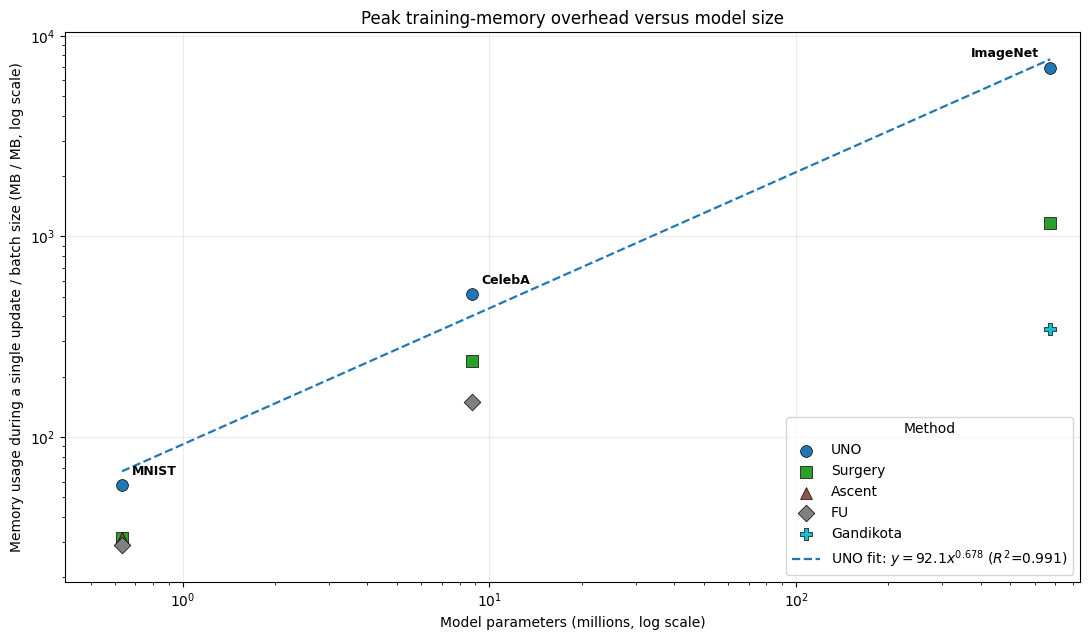

Saved summary: /Users/pinak/Documents/Github/forget/data/models/normalized_peak_memory_summary.csv
Saved plot: /Users/pinak/Documents/Github/forget/data/models/peak_memory_per_batch_image_mb_vs_model_parameters.png


In [15]:
fig, ax = plt.subplots(figsize=(11, 6.5))
x_column = "model_parameters_millions"
value_column = "peak_memory_diff_per_batch_image_mb"
error_column = value_column + "_std"

methods_to_plot = [
    "UNO",
    # "UNO-S",  # Intentionally disabled; uncomment to restore UNO-S points.
    "Surgery",
    "Ascent",
    # "Ascent-Descent",  # Intentionally disabled; uncomment to restore it.
    "FU",
    "Gandikota",
]
methods_to_plot = [
    method for method in methods_to_plot if method in set(summary["method"])
]
colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(methods_to_plot)))
markers = ("o", "s", "^", "D", "P", "X", "v")

for method, color, marker in zip(methods_to_plot, colors, markers):
    method_rows = summary[summary["method"] == method].copy()
    method_rows = method_rows.sort_values(x_column)
    method_x = method_rows[x_column].to_numpy(dtype=float)
    method_y = method_rows[value_column].to_numpy(dtype=float)
    method_error = method_rows[error_column].to_numpy(dtype=float)

    ax.scatter(
        method_x,
        method_y,
        s=72,
        marker=marker,
        color=color,
        edgecolor="black",
        linewidth=0.5,
        label=method,
        zorder=3,
    )
    if np.any(method_error > 0):
        ax.errorbar(
            method_x,
            method_y,
            yerr=method_error,
            fmt="none",
            ecolor=color,
            capsize=3,
            alpha=0.8,
            zorder=2,
        )

uno_rows = summary[summary["method"] == "UNO"].sort_values(x_column)
uno_x = uno_rows[x_column].to_numpy(dtype=float)
uno_y = uno_rows[value_column].to_numpy(dtype=float)
for (_, row), x_value, y_value in zip(uno_rows.iterrows(), uno_x, uno_y):
    dataset_name = str(row["dataset"])
    label_offset = (-8, 8) if dataset_name == "ImageNet" else (7, 7)
    horizontal_alignment = "right" if dataset_name == "ImageNet" else "left"
    ax.annotate(
        dataset_name,
        (x_value, y_value),
        xytext=label_offset,
        textcoords="offset points",
        ha=horizontal_alignment,
        fontsize=9,
        fontweight="bold",
    )
if len(uno_rows) >= 2 and np.all(uno_x > 0) and np.all(uno_y > 0):
    log_x = np.log10(uno_x)
    log_y = np.log10(uno_y)
    exponent, log_coefficient = np.polyfit(log_x, log_y, deg=1)
    coefficient = 10 ** log_coefficient
    fit_x = np.geomspace(uno_x.min(), uno_x.max(), 200)
    fit_y = coefficient * fit_x ** exponent
    predicted_log_y = exponent * log_x + log_coefficient
    residual_sum = np.sum((log_y - predicted_log_y) ** 2)
    total_sum = np.sum((log_y - log_y.mean()) ** 2)
    r_squared = 1 - residual_sum / total_sum if total_sum > 0 else 1.0
    ax.plot(
        fit_x,
        fit_y,
        linestyle="--",
        color=colors[methods_to_plot.index("UNO")],
        linewidth=1.6,
        label=(
            rf"UNO fit: $y={coefficient:.3g}x^{{{exponent:.3f}}}$ "
            rf"($R^2$={r_squared:.3f})"
        ),
        zorder=1,
    )

plotted_values = summary[summary["method"].isin(methods_to_plot)][value_column]
ax.set_yscale("log")
ax.set_ylim(plotted_values.min() * 0.65, plotted_values.max() * 1.5)
minimum_parameters = summary[x_column].min()
maximum_parameters = summary[x_column].max()
ax.set_xscale("log")
ax.set_xlim(minimum_parameters * 0.65, maximum_parameters * 1.25)
ax.set_xlabel("Model parameters (millions, log scale)")
ax.set_ylabel("Memory usage during a single update / batch size (MB / MB, log scale)")
ax.set_title("Peak training-memory overhead versus model size")
ax.grid(alpha=0.25)
ax.legend(title="Method", loc="lower right")

fig.tight_layout()
fig.savefig(output_plot, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved summary: {output_csv}")
print(f"Saved plot: {output_plot}")

### Interpretation notes

- The plotted quantity is incremental peak CUDA allocation during a profiled training call, not total device memory occupancy.
- The first three measurements of every run are treated as warm-up and excluded before taking the maximum. Change `warmup_rows` in the setup cell to adjust this cutoff.
- The x-coordinate is the generative model's parameter count in millions and is displayed logarithmically; classifier parameter counts are not used.
- The y-coordinate is `peak_memory_diff_mb / (batch_size * image_size_mb)`, expressed as MB of incremental peak memory per MB of input-image batch memory and displayed logarithmically.
- `image_size_mb` is the in-memory float32 input tensor size, not the compressed JPEG/PNG file size: 0.00299 MB for MNIST, 0.046875 MB for CelebA, and 0.75 MB for ImageNet.
- Batch-image normalization does not remove fixed allocations, activation-size differences, optimizer state, precision, or implementation-specific memory behavior.
- UNO-S and Ascent-Descent are retained in the exported summary but excluded from the scatter plot by their commented entries in `methods_to_plot`.
- The UNO power law $y=ax^b$ is fit by ordinary least squares after applying $\log_{10}$ to both axes. Its equation and log-space $R^2$ appear in the legend; with only three datasets, it is descriptive rather than a scaling-law estimate.
- Alternating methods such as UNO-S and Ascent-Descent are represented by the maximum across both update types.